# Level 1: Scientific Problem Framing and Python Foundation
**Project Title:** HydroSense-Kenya  
**Objective:** Translate real-world irrigation challenges into a structured scientific computing system.

---

## 1. Problem Statement (Kenyan Context)
In the semi-arid regions of Kenya, such as Machakos and Laikipia, smallholder farmers rely heavily on rain-fed agriculture. However, erratic rainfall patterns due to climate change have made traditional farming unpredictable. Over-irrigation leads to water wastage and nutrient leaching, while under-irrigation results in crop wilting and reduced yields. 

The **HydroSense-Kenya** project addresses this by building a scientific computing system that uses daily weather and soil sensor data to model the water balance of specific crop zones (Tomato, Kale, Maize). By calculating daily Evapotranspiration (ET) and monitoring soil moisture ($S_t$), the system provides a data-driven recommendation for when and how much to irrigate. This minimizes water usage while ensuring the soil moisture stays within the target range required for optimal plant growth. Our central scientific question is: *How can we model water availability and simulate future soil moisture to recommend an irrigation plan that prevents moisture stress while conserving water resources?*

## 2. Loading Datasets and Inspecting Structure

In [ ]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the src directory is accessible
sys.path.append(os.path.abspath('../src'))
from simulation import calculate_et, water_balance_model
from data_cleaning import aggregate_daily_weather

# Load the initial datasets
weather_raw = pd.read_csv('../data/raw/weather_daily.csv')
soil_raw = pd.read_csv('../data/raw/soil_sensor_data.csv')
params_raw = pd.read_csv('../data/raw/crop_zone_parameters.csv')

print("--- Weather Data Structure ---")
print(weather_raw.info())
print("\n--- Soil Sensor Data Structure ---")
print(soil_raw.info())
print("\n--- Crop Zone Parameters Structure ---")
print(params_raw.info())

--- Weather Data Structure ---
<class 'pandas.DataFrame'>
RangeIndex: 2945 entries, 0 to 2944
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ts                   2945 non-null   str    
 1   rg1                  2945 non-null   float64
 2   rg2                  2945 non-null   float64
 3   rg1tt                2945 non-null   float64
 4   rg2tt                2945 non-null   float64
 5   rg1tp                2945 non-null   float64
 6   rg2tp                2945 non-null   float64
 7   temp_bmx             2945 non-null   float64
 8   press_bmx            2945 non-null   float64
 9   temp_mcp             2945 non-null   float64
 10  temp_sht             2945 non-null   float64
 11  humidity_sht         2945 non-null   float64
 12  si1145_vis           2945 non-null   int64  
 13  si1145_ir            2945 non-null   int64  
 14  si1145_uv            2945 non-null   int64  
 15  wind_spd          

## 3. Data Dictionary
This dictionary maps the raw sensor headers provided in the dataset to the scientific variables used in our mathematical model.

| Variable | Raw Header | Scientific Term | Unit | Description |
| :--- | :--- | :--- | :--- | :--- |
| **Timestamp** | `ts` | $t$ | ISO8601 | Time of recording |
| **Rainfall** | `rg1` | $R_t$ | mm | Daily rainfall from rain gauge 1 |
| **Temperature** | `temp_sht` | $T$ | °C | Ambient temperature from SHT sensor |
| **Humidity** | `humidity_sht` | $H$ | % | Relative humidity from SHT sensor |
| **Wind Speed** | `wind_spd` | $W$ | m/s | Anemometer reading |
| **Solar Index** | `si1145_uv` | $Solar$ | Index | UV/Solar intensity index |
| **Soil Moisture**| `soil_moisture_pct` | $S_t$ | % | Volumetric water content |
| **Drainage** | N/A | $D_t$ | mm | Water lost beyond field capacity |

In [20]:
# We use the functions imported from src/simulation.py

def test_model_logic():
    # Sample inputs based on the dataset logic
    temp = 24.2
    wind = 0.5
    solar = 0.0 # Night/Low UV example
    hum = 94.1
    
    et = calculate_et(temp, wind, solar, hum)
    s_next = water_balance_model(s_t=33.2, r_t=0.0, i_t=5.0, et_t=et, drainage_coeff=0.18, field_capacity=41.0)
    
    print(f"Initial Test Calculation:")
    print(f"Estimated ET: {et:.2f} mm/day")
    print(f"Predicted Soil Moisture: {s_next:.2f}%")

test_model_logic()

Initial Test Calculation:
Estimated ET: 0.73 mm/day
Predicted Soil Moisture: 37.47%


## Ploting a Simple Daily Rainfall Bar Graph

         date  rainfall_mm     temp_c  humidity_pct  wind_speed_mps  \
0  2026-03-01          0.0  20.952632     77.738947        0.313684   
1  2026-03-02          0.0  21.526316     75.563158        0.361053   
2  2026-03-03          0.0  21.769474     75.797895        0.443158   
3  2026-03-04          1.0  20.120000     82.103158        0.250526   
4  2026-03-05          2.6  19.843158     83.932632        0.388421   

   solar_index  
0            0  
1            0  
2            0  
3            0  
4            0  


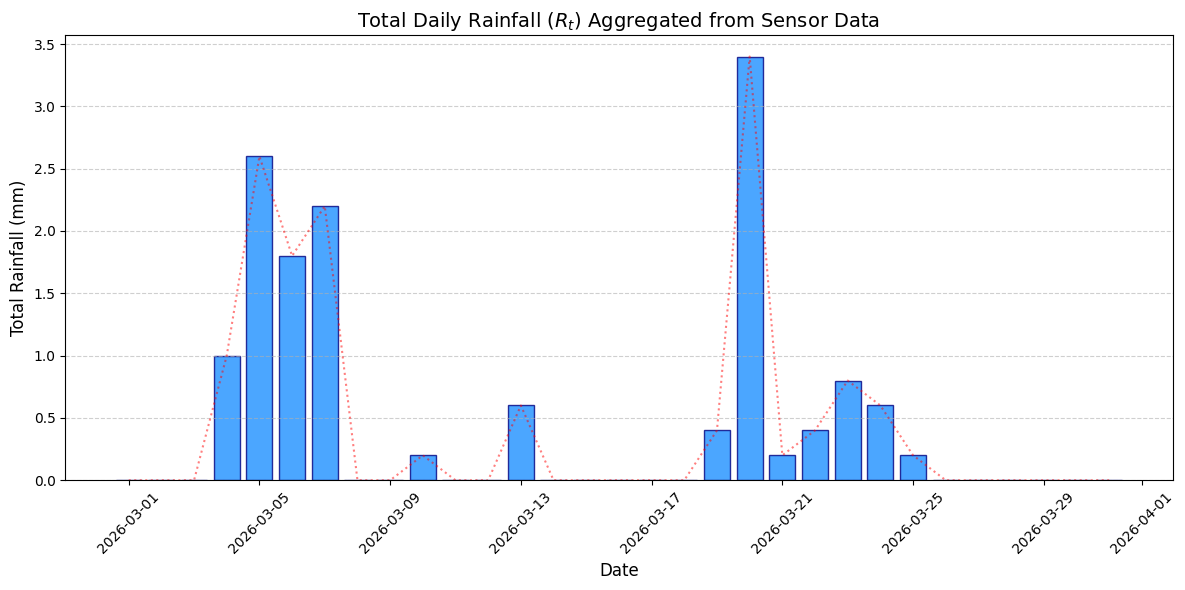

In [ ]:
# Aggregate data to daily level using function from data_cleaning.py
daily_weather = aggregate_daily_weather(weather_raw)
print(daily_weather.head())

# 4. Scientific Plot: Daily Rainfall against Date
plt.figure(figsize=(12, 6))
plt.bar(daily_weather['date'], daily_weather['rainfall_mm'], color='dodgerblue', edgecolor='navy', alpha=0.8)

# Formatting the plot to scientific standards
plt.title('Total Daily Rainfall ($R_t$) Aggregated from Sensor Data', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Rainfall (mm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

# Adding a trend line for visual aid
plt.plot(daily_weather['date'], daily_weather['rainfall_mm'], color='red', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Assumptions and Limitations
### Assumptions:
- **Uniformity:** We assume soil moisture readings from a single sensor represent the entire zone.
- **ET Accuracy:** The simplified ET formula is assumed to be a sufficient approximation for the Kenyan climate without needing a full Penman-Monteith calculation.
- **Linear Drainage:** Drainage is assumed to happen linearly only when the field capacity is exceeded.

### Limitations:
- **Sensor Faults:** Raw data contains `NA` values and potential sensor anomalies (e.g., zero humidity) that are not yet cleaned.
- **Runoff:** The current model does not account for surface runoff during extreme rainfall events ($R_t > 50$mm).